<a href="https://colab.research.google.com/github/237marek9-per/Problem_poctu_nepozorovanych_druhov/blob/main/Eggholder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

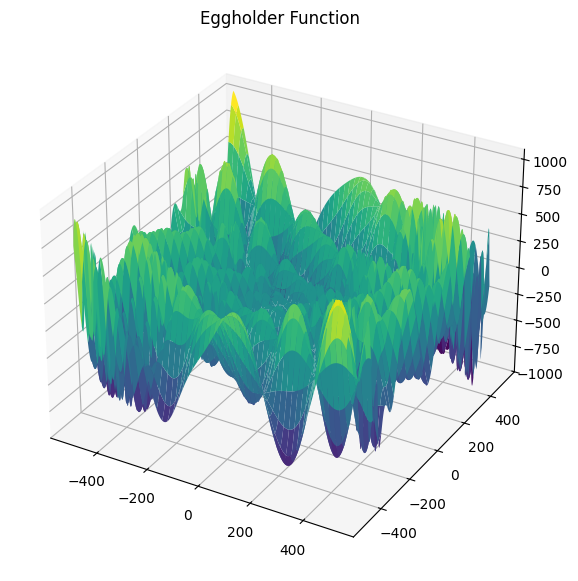

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import pandas as pd


# Eggholder function
def eggholderova_funkcia(v):
    x, y = v
    return -(y+47)*np.sin(np.sqrt(abs(x/2 + y + 47))) - x*np.sin(np.sqrt(abs(x - (y+47))))

# ----------- GRAF -----------
x = np.linspace(-512, 512, 400)
y = np.linspace(-512, 512, 400)
X, Y = np.meshgrid(x, y)
Z = eggholderova_funkcia([X, Y])

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', linewidth=0)
ax.set_title("Eggholder Function")
plt.show()


In [ ]:

# Funkcia na hľadanie lokálneho minima
def najdi_lokalne_minimum():
    pociatocny_bod = np.random.uniform(-512, 512, size=2)
    vysledok = minimize(eggholderova_funkcia, pociatocny_bod, method='L-BFGS-B',
                        bounds=[(-512, 512), (-512, 512)])
    return round(vysledok.x[0], 2), round(vysledok.x[1], 2)


N_velkost = 750
m_velkost = 250

# Nasimulujeme prvé hľadanie (Vzorka N)
data_N = [najdi_lokalne_minimum() for _ in range(N_velkost)]
df_N_raw = pd.DataFrame(data_N, columns=['x', 'y'])

# Nasimulujeme druhé hľadanie (Vzorka m)
data_m = [najdi_lokalne_minimum() for _ in range(m_velkost)]
df_m_raw = pd.DataFrame(data_m, columns=['x', 'y'])

# Pomocný stĺpec pre identifikáciu unikátnych súradníc
df_N_raw['id_bod'] = df_N_raw.apply(lambda r: f"{r['x']}_{r['y']}", axis=1)
df_m_raw['id_bod'] = df_m_raw.apply(lambda r: f"{r['x']}_{r['y']}", axis=1)



# 1. Zoskupíme prvú vzorku a spočítame výskyty
vzorka_N = df_N_raw.groupby('id_bod').size().reset_index(name='pocet')

# 2. Vytvoríme mapu mien: unikátny bod -> extrem_1, extrem_2...
# zoradenie zabezpečí, že pomenovanie bude konzistentné
vzorka_N = vzorka_N.sort_values(by='pocet', ascending=True).reset_index(drop=True)
vzorka_N['nazov_extremu'] = [f"extrem_{i+1}" for i in range(len(vzorka_N))]

# -------- ANALÝZA UNSEEN SPECIES --------
unikaty_N = set(df_N_raw['id_bod'])
nove_v_m = df_m_raw[~df_m_raw['id_bod'].isin(unikaty_N)]
pocet_novych = nove_v_m['id_bod'].nunique()

# -------- ZÁPIS DO TXT (Iba názov a počet) --------
vzorka_N.to_csv("extremy.txt", sep="\t", index=False, header=False, columns=['nazov_extremu', 'pocet'])

# -------- VÝSTUP --------
print(f"Hotovo! Súbor 'extremy.txt' obsahuje {len(vzorka_N)} riadkov.")
print(f"Najčastejší nález: {vzorka_N.iloc[0]['nazov_extremu']} (nájdený {vzorka_N.iloc[0]['pocet']}-krát)")
print(f"Počet nových (unseen) druhov v druhej vzorke (m): {pocet_novych}")

Hotovo! Súbor 'extremy.txt' obsahuje 79 riadkov.
Najčastejší nález: extrem_1 (nájdený 1-krát)
Počet nových (unseen) druhov v druhej vzorke (m): 2
